In [1]:
from gvabm.city_data import subsampled_city_data, subsample_weights
import numpy as np

has_event = np.array([1 if len(c['events']) > 0 else 0 for c in subsampled_city_data])
num_events = np.array([len(c['events']) for c in subsampled_city_data])

pop_l = np.array([c['params'].population for c in subsampled_city_data])
arm_density_l = np.array([c['params'].arm_density for c in subsampled_city_data])
pop_density_l = np.array([c['params'].population_density for c in subsampled_city_data])

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

sev_lists = [[e.fatalities for e in c['events']] for c in subsampled_city_data]
sev_vals = []
sev_region_idx = []
for r, lst in enumerate(sev_lists):
    sev_vals.extend(lst)
    sev_region_idx.extend([r] * len(lst))
sev_vals = np.array(sev_vals)
sev_region_idx = np.array(sev_region_idx)
num_events = np.array([len(lst) for lst in sev_lists])

In [3]:
import pymc as pm
import numpy as np
import arviz as az
from pytensor.tensor.math import gammainc

with pm.Model() as model:
    # Severity distribution parameters
    k_sev = pm.Exponential("k_sev", 1.0)

    intercept = pm.Exponential("intercept", 1.0)

    beta = pm.Deterministic(
        "lambda_sev", intercept )
    
    threshold = 3.0 - 1e-6

    sev_obs_dist = pm.Truncated.dist(
        pm.Weibull.dist(alpha=beta, beta=k_sev),
        lower=threshold,
    )
    # print(subsample_weights.shape, sev_region_idx.shape, sev_vals.shape)
    # print(subsample_weights[sev_region_idx].shape, pm.logp(sev_obs_dist, sev_vals).shape)
    sev_logp_i = pm.logp(sev_obs_dist, sev_vals)
    pm.Deterministic('sev_ll_i', sev_logp_i)

    sev_logp = subsample_weights[sev_region_idx] * pm.logp(sev_obs_dist, sev_vals)
    pm.Potential('sev_likelihood', sev_logp.sum())
    pm.Deterministic('sev_ll', sev_logp.sum())

    p_record = pm.Deterministic(
        "p_record",
        pm.math.exp(-(threshold / k_sev)**beta)
    )

    alpha_count = pm.Normal("alpha_count", mu=0, sigma=5)
    log_lambda = alpha_count + np.log(pop_l)
    lambda_ = pm.Deterministic("lambda_", pm.math.exp(log_lambda))
    counts_dist = pm.Poisson.dist(mu=lambda_ * p_record)

    count_logp_i = pm.logp(counts_dist, num_events)
    pm.Deterministic('count_ll_i', count_logp_i)
    # total_logp_i = sev_logp_i + count_logp_i
    # pm.Deterministic('total_ll_i', total_logp_i)
    counts_logp = subsample_weights * pm.logp(counts_dist, num_events)
    pm.Potential('counts_likelihood', counts_logp.sum())
    pm.Deterministic('counts_ll', counts_logp.sum())
    trace = pm.sample(1000, tune=1000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k_sev, intercept, alpha_count]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [4]:
from gvabm.waic_eval import estimate_PLLD, estimate_WAIC_correction, WAIC_metric
# pll_i = trace.posterior['total_ll_i'].values.reshape(-1, len(subsampled_city_data), 1).transpose(1, 0, 2)
pll_i_sev = trace.posterior['sev_ll_i'].values.reshape(-1, len(sev_region_idx), 1).transpose(1, 0, 2)
pll_i_count = trace.posterior['count_ll_i'].values.reshape(-1, len(subsampled_city_data), 1).transpose(1, 0, 2)

pll_i_sev_full = np.zeros_like(pll_i_count)
pll_i_sev_full[sev_region_idx,:,0] = pll_i_sev[:,:,0]
pll_i_sev = pll_i_sev_full
pll_i = pll_i_sev + pll_i_count

In [5]:
waic, waic_se = WAIC_metric(pll_i, subsample_weights)
print(f'WAIC: {waic:.2f} +/- {waic_se:.8f}')

WAIC: -1201.91 +/- 0.28527481


In [19]:
pll_i_sev.mean(), pll_i_count.mean()

(np.float64(0.0), np.float64(-1.4971215235027147))

In [16]:
print(trace.posterior["sev_ll"].stack(samples=("chain", "draw")).values.mean())
print(trace.posterior["counts_ll"].stack(samples=("chain", "draw")).values.mean())
(trace.posterior["sev_ll"].stack(samples=("chain", "draw")).values + trace.posterior["counts_ll"].stack(samples=("chain", "draw")).values).mean()


-371.8094370572764
-838.4987467924086


np.float64(-1210.308183849685)

In [18]:
import pymc as pm
import numpy as np
import arviz as az
from pytensor.tensor.math import gammainc

with pm.Model() as model:
    # Severity distribution parameters
    k_sev = pm.Exponential("k_sev", 1.0)

    pd_weight = pm.Exponential("pd_weight", 1.0)
    arm_weight = pm.Exponential("arm_weight", 1.0)
    intercept = pm.Exponential("intercept", 1.0)

    beta = pm.Deterministic(
        "lambda_sev", intercept + pd_weight * (pop_density_l / 1e5) + arm_weight * (arm_density_l * 100 / pop_density_l)
    )
    
    threshold = 3.0 - 1e-6

    sev_obs_dist = pm.Truncated.dist(
        pm.Weibull.dist(alpha=beta[sev_region_idx], beta=k_sev),
        lower=threshold,
    )
    # print(subsample_weights.shape, sev_region_idx.shape, sev_vals.shape)
    # print(subsample_weights[sev_region_idx].shape, pm.logp(sev_obs_dist, sev_vals).shape)

    sev_logp = subsample_weights[sev_region_idx] * pm.logp(sev_obs_dist, sev_vals)
    pm.Potential('sev_likelihood', sev_logp.sum())
    pm.Deterministic('sev_ll', sev_logp.sum())

    p_record = pm.Deterministic(
        "p_record",
        pm.math.exp(-(threshold / k_sev)**beta)
    )

    alpha_count = pm.Normal("alpha_count", mu=0, sigma=5)
    log_lambda = alpha_count + np.log(pop_l)
    lambda_ = pm.Deterministic("lambda_", pm.math.exp(log_lambda))
    counts_dist = pm.Poisson.dist(mu=lambda_ * p_record)
    
    counts_logp = subsample_weights * pm.logp(counts_dist, num_events)
    pm.Potential('counts_likelihood', counts_logp.sum())
    pm.Deterministic('counts_ll', counts_logp.sum())
    trace = pm.sample(1000, tune=1000, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [k_sev, pd_weight, arm_weight, intercept, alpha_count]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


-371.80152120634307
-838.2145946564787


np.float64(-1210.0161158628216)

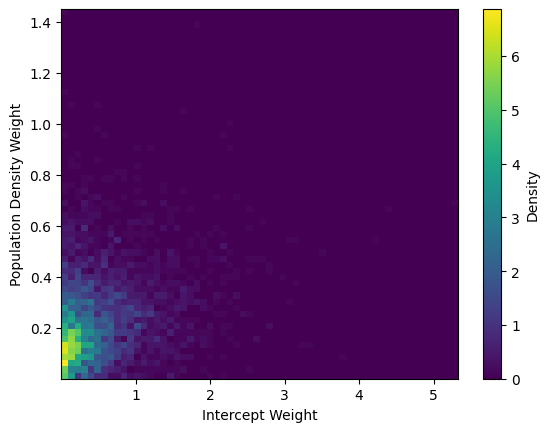

In [20]:
#plot densities of posterior distributions
import matplotlib.pyplot as plt
x_samples = trace.posterior['pd_weight'].values.flatten()
y_samples = trace.posterior['arm_weight'].values.flatten()
plt.hist2d(x_samples, y_samples, bins=60, density=True)
plt.xlabel('Intercept Weight')
plt.ylabel('Population Density Weight')
plt.colorbar(label='Density')
plt.show()

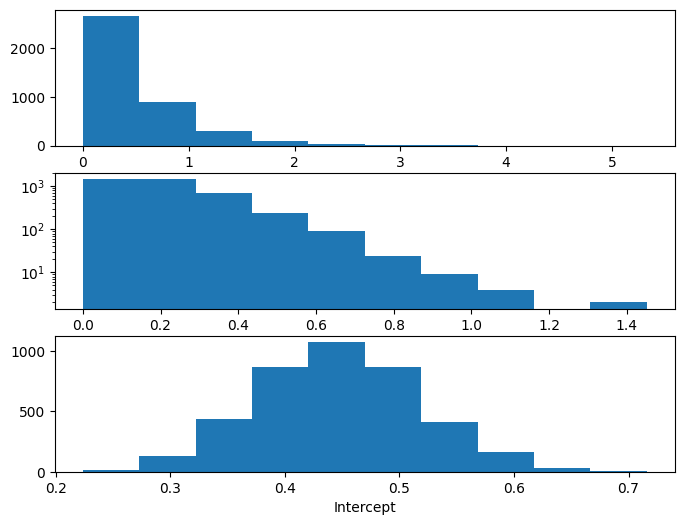

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6))
axes[0].hist(trace.posterior['pd_weight'].values.flatten())
axes[0].set_xlabel('Population Density Weight')
axes[1].hist(trace.posterior['arm_weight'].values.flatten())
axes[1].set_xlabel('Armed Density Weight')
axes[1].set_yscale('log')
axes[2].hist(trace.posterior['intercept'].values.flatten())
axes[2].set_xlabel('Intercept')
plt.show()

In [4]:
import pymc as pm
import numpy as np
import arviz as az
from pytensor.tensor.math import gammainc

with pm.Model() as model:
    # Severity distribution parameters
    alpha = pm.Exponential("alpha_sev", 1.0)

    pd_weight = pm.Exponential("pd_weight", 1.0)
    arm_weight = pm.Exponential("arm_weight", 1.0)
    intercept = pm.Exponential("intercept", 1.0)

    beta = pm.Deterministic(
        "beta_sev", intercept + pd_weight * (pop_density_l / 1e5) + arm_weight * (arm_density_l * 100 / pop_density_l)
    )
    
    threshold = 3.0 - 1e-6

    sev_obs_dist = pm.Truncated.dist(
        pm.Gamma.dist(alpha=alpha, beta=beta[sev_region_idx]),
        lower=threshold,
    )
    # print(subsample_weights.shape, sev_region_idx.shape, sev_vals.shape)
    # print(subsample_weights[sev_region_idx].shape, pm.logp(sev_obs_dist, sev_vals).shape)

    sev_logp = subsample_weights[sev_region_idx] * pm.logp(sev_obs_dist, sev_vals)
    pm.Potential('sev_likelihood', sev_logp.sum())
    pm.Deterministic('sev_ll', sev_logp.sum())

    p_record = pm.Deterministic(
        "p_record",
        1.0 - gammainc(alpha, beta * threshold)
    )

    alpha_count = pm.Normal("alpha_count", mu=0, sigma=5)
    log_lambda = alpha_count + np.log(pop_l)
    lambda_ = pm.Deterministic("lambda_", pm.math.exp(log_lambda))
    counts_dist = pm.Poisson.dist(mu=lambda_ * p_record)
    
    counts_logp = subsample_weights * pm.logp(counts_dist, num_events)
    pm.Potential('counts_likelihood', counts_logp.sum())
    pm.Deterministic('counts_ll', counts_logp.sum())
    trace = pm.sample(1000, tune=1000, target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_sev, pd_weight, arm_weight, intercept, alpha_count]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 90 seconds.


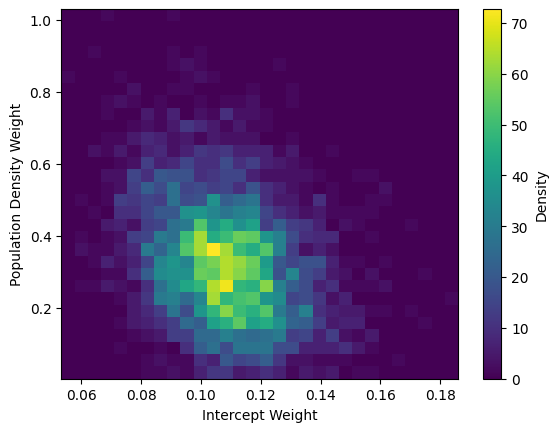

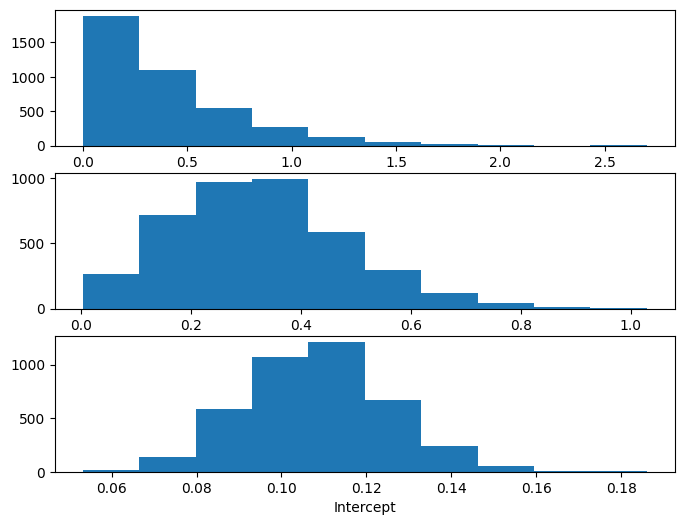

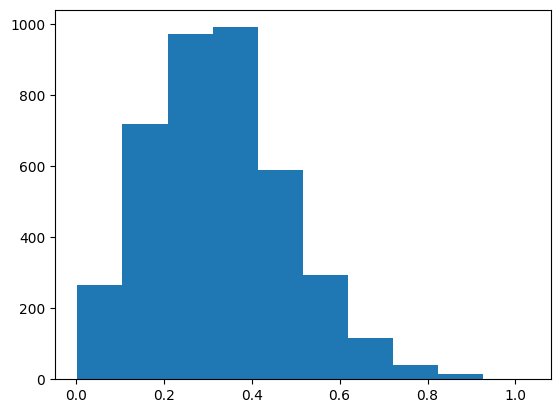

In [7]:
plt.hist(trace.posterior['arm_weight'].values.flatten())
plt.show()

In [8]:
(trace.posterior["sev_ll"].stack(samples=("chain", "draw")).values + trace.posterior["counts_ll"].stack(samples=("chain", "draw")).values).mean()

np.float64(-1212.190635589597)

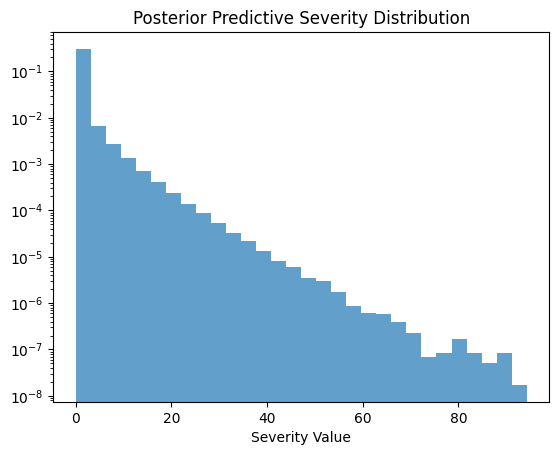

In [9]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

post_alpha = trace.posterior["alpha_sev"].stack(samples=("chain", "draw")).values
post_beta = trace.posterior["beta_sev"].stack(samples=("chain", "draw")).values

sev_dist_posterior = pm.Gamma.dist(alpha=post_alpha, beta=post_beta)

sev_samples = pm.draw(sev_dist_posterior, draws=10).flatten()
plt.hist(sev_samples, bins=30, density=True, alpha=0.7, label="Posterior Predictive Severity")
plt.yscale("log")

plt.title("Posterior Predictive Severity Distribution")
plt.xlabel("Severity Value")
plt.show()

In [ ]:
# ----------------------------
# Bayesian model
# ----------------------------
with pm.Model() as joint_model:
    # ----- Hyperpriors for shared region effect -----
    sigma_region = pm.Exponential("sigma_region", 1.0)
    # Shared region-level random effect (mean 0)
    region_re = pm.Normal("region_re", mu=0.0, sigma=sigma_region, shape=R)

    # ----- Count (frequency) submodel -----
    alpha_count = pm.Normal("alpha_count", 0.0, 5.0)
    beta_count = pm.Normal("beta_count", 0.0, 2.0)
    # linear predictor for log-rate per region
    log_lambda = alpha_count + beta_count * retailer + region_re  + np.log(population)
    lambda_ = pm.math.exp(log_lambda)
    # observed counts (Poisson)
    y_count = pm.Poisson("y_count", mu=lambda_, observed=num_events)
    
    # ----- Severity submodel (event-level) -----
    # intercept and slope for severity mean (on log scale)
    alpha_sev = pm.Normal("alpha_sev", 0.0, 5.0)
    beta_sev = pm.Normal("beta_sev", 0.0, 2.0)
    # dispersion parameter for Gamma (sigma > 0)
    sigma_sev = pm.Exponential("sigma_sev", 1.0)
    # expected severity per event (linked to region-level predictors and shared RE)
    # use retailer at the region associated with each event
    mu_sev_log = alpha_sev + beta_sev * retailer[sev_region_idx] + region_re[sev_region_idx]
    mu_sev = pm.math.exp(mu_sev_log)   # positive mean
    # Gamma parametrized by mu and sigma (PyMC supports mu/sigma)
    sev_obs = pm.Gamma("sev_obs", mu=mu_sev, sigma=sigma_sev, observed=sev_vals)
    
    # ----- Derived (for convenience) -----
    # expected count per region (posterior latent)
    expected_count = pm.Deterministic("expected_count", lambda_)
    # expected severity per event for each region (posterior latent)
    expected_severity_region = pm.Deterministic(
        "expected_severity_region",
        pm.math.exp(alpha_sev + beta_sev * retailer + region_re)
    )
    # expected total harm per region = expected_count * expected_severity_region
    expected_total_harm = pm.Deterministic(
        "expected_total_harm",
        expected_count * expected_severity_region
    )

    # ----- Sampling -----
    trace = pm.sample(
        draws=1000, tune=1000, target_accept=0.9,
        return_inferencedata=True
    )

# Summarize posterior
az.summary(trace, var_names=[
    "alpha_count","beta_count","alpha_sev","beta_sev",
    "sigma_region","sigma_sev"
])


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_region, region_re, alpha_count, beta_count, alpha_sev, beta_sev, sigma_sev]


/home/andrew/anaconda3/envs/gvabm/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_count,-11.039,0.651,-12.239,-9.856,0.016,0.012,1643.0,1628.0,1.00
beta_count,0.181,0.426,-0.585,1.011,0.010,0.008,1724.0,2031.0,1.00
alpha_sev,1.022,0.415,0.251,1.768,0.010,0.013,1789.0,1642.0,1.00
beta_sev,0.283,0.261,-0.210,0.763,0.006,0.009,1933.0,1666.0,1.00
sigma_region,0.171,0.181,0.011,0.429,0.010,0.023,240.0,291.0,1.02
sigma_sev,2.600,0.548,1.727,3.665,0.011,0.012,2512.0,2397.0,1.00


In [ ]:
import pymc as pm
import numpy as np
import arviz as az
from pytensor.tensor.math import gammainc

with pm.Model() as model:
    # Severity distribution parameters
    alpha = pm.Exponential("alpha_sev", 1.0)
    beta = pm.Exponential("beta_sev", 1.0)
    threshold = 3.0 - 1e-6

    mu_sev = pm.Deterministic("mu_sev", alpha / beta)
    sigma_sev = pm.Deterministic("sigma_sev", pm.math.sqrt(alpha) / beta)
    sev_obs_dist = pm.Truncated.dist(
        pm.Gamma.dist(alpha=alpha, beta=beta),
        lower=threshold,
    )

    sev_logp = subsample_weights[sev_region_idx] * pm.logp(sev_obs_dist, sev_vals)
    pm.Potential('sev_likelihood', sev_logp.sum())
    pm.Deterministic('sev_ll', sev_logp.sum())

    alpha = (mu_sev / sigma_sev)**2
    beta = mu_sev / sigma_sev**2

    p_record = pm.Deterministic(
        "p_record",
        1.0 - gammainc(alpha, beta * threshold)
    )

    alpha_count = pm.Normal("alpha_count", mu=0, sigma=5)
    log_lambda = alpha_count + np.log(pop_l)
    lambda_ = pm.Deterministic("lambda_", pm.math.exp(log_lambda))
    counts_dist = pm.Poisson.dist(mu=lambda_ * p_record)
    
    counts_logp = subsample_weights * pm.logp(counts_dist, num_events)
    pm.Potential('counts_likelihood', counts_logp.sum())
    pm.Deterministic('counts_ll', counts_logp.sum())
    trace = pm.sample(1000, tune=1000, target_accept=0.9)